# Desafio Lighthouse - Análise de Dados e IA
## Empresa: LH Nautical

**Autor:** Mauro Tessaro Jr  
**Data:** Março 2026  

### Sobre o projeto
A LH Nautical é uma empresa de varejo náutico com loja física em Florianópolis 
e e-commerce nacional. <br>
O presente notebook consolida as análises solciitadas, 
cobrindo desde limpeza de dados até modelos preditivos e sistemas de recomendação.

### Stack utilizada
- **Python 3.11** para tratamento de dados e modelos
- **DuckDB** para queries SQL embarcadas
- **Pandas** para manipulação de DataFrames
- **Matplotlib** para visualizações e gráficos
- **NumPy** para similaridade de cosseno
- **Requests** para consumo da API do Banco Central
- **Unicodedata** para normalização de texto para limpeza de categorias

In [1]:
import pandas as pd
import duckdb

# Caminhos dos datasets
VENDAS = "vendas_2023_2024.csv"
PRODUTOS = "produtos_raw.csv"
CUSTOS = "custos_importacao.json"
CLIENTES = "clientes_crm.json"

## __Q1. EDA - Análise Exploratória de Dados__

In [2]:
# Carrega o CSV de vendas sem nenhuma transformação
df_vendas = pd.read_csv(VENDAS)

### Parte 1 - Visão Geral

In [3]:
print("Quantidade total de Linhas:", len(df_vendas))
print("Quantidade total de Colunas:", len(df_vendas.columns))

Quantidade total de Linhas: 9895
Quantidade total de Colunas: 6


In [4]:
print("\nIntervalo de datas analisado:")
print("Data inicial:", df_vendas['sale_date'].min())
print("Data final:", df_vendas['sale_date'].max())


Intervalo de datas analisado:
Data inicial: 01-01-2023
Data final: 31-12-2024


### Q1.1 - SQL com DuckDB

In [5]:
conn = duckdb.connect()

resultado = conn.execute("""
    SELECT
        COUNT(*)                        AS total_linhas,
        MIN(sale_date)                  AS data_minima,
        MAX(sale_date)                  AS data_maxima,
        MIN(total)                      AS valor_minimo,
        MAX(total)                      AS valor_maximo,
        ROUND(AVG(total), 2)            AS valor_medio
    FROM read_csv_auto('vendas_2023_2024.csv')
""").df()

print(resultado.to_string(index=False))

 total_linhas data_minima data_maxima  valor_minimo  valor_maximo  valor_medio
         9895  01-01-2023  31-12-2024         294.5     2222973.0    263797.83


### Parte 2 - Análise de valores numéricos 

### Q1.2 - Validação, incluso na query sql anterior
Valor máximo registrado na coluna total: **R$ 2.222.973,00**

In [6]:
# PARTE 2: Análise da coluna total
print("\nValor mínimo em total:", df_vendas['total'].min())
print("Valor máximo em total:", df_vendas['total'].max())
print("Valor médio em total:", round(df_vendas['total'].mean(), 2))


Valor mínimo em total: 294.5
Valor máximo em total: 2222973.0
Valor médio em total: 263797.83


### Parte 3 - Confiabilidade
#### dataset: vendas_2023_2024.csv

In [7]:
# Identifica possíveis outliers usando IQR
Q1 = df_vendas['total'].quantile(0.25)
Q3 = df_vendas['total'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_vendas[df_vendas['total'] > Q3 + 1.5 * IQR]
print(f"\nOutliers detectados: {len(outliers)}")
print(f"\nValor mínimo dos outliers: R$ {outliers['total'].min():,.2f}")
print(f"Valor máximo dos outliers: R$ {outliers['total'].max():,.2f}")

# Qualidade geral
print("\nValores nulos por coluna:")
print(df_vendas.isnull().sum())

# Verifica duplicatas
print(f"\nLinhas duplicadas: {df_vendas.duplicated().sum()}")


Outliers detectados: 1018

Valor mínimo dos outliers: R$ 814,995.50
Valor máximo dos outliers: R$ 2,222,973.00

Valores nulos por coluna:
id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64

Linhas duplicadas: 0


### Q1.3 - Diagnóstico de confiabilidade do dataset: vendas_2023_2024.csv

O dataset vendas_2023_2024.csv apresenta boa integridade. Nenhum valor nulo em nenhuma das 6 colunas e não há registros duplicados. Cobre exatamente 2 anos de vendas (janeiro 2023 a dezembro 2024), com 9.895 registros. A metade das vendas ficou abaixo de R$ 82.225,00. Isso significa que a média (R$ 263.797,83) está "puxada para cima" por vendas muito altas. Utilizando o critério padrão de 1,5× IQR identificou-se 1.018 vendas acima de R$ 814.995,50, cerca de 10% do total. O dataset está pronto para análises e contagens mas exige atenção aos outliers. Podem ser valores de vendas legítimas de produtos de alto valor mas antes de fazer previsões, é recomendável investigar esses casos com o time de negócios para confirmar se são reais.

## __Q2 - Limpeza e normalização do dataset: produtos_raw.csv__

#### Q2 - Parte 1: Padronizar categorias em: eletrônicos, propulsão, ancoragem

In [8]:
# Lê o csv de produtos e armazena em um dataframe:
df_produtos = pd.read_csv(PRODUTOS)

# Mostra quantas linhas e colunas tem o DataFrame (linhas, colunas)
print("número de linhas =", df_produtos.shape[0])
print("número de colunas =", df_produtos.shape[1])

# Mostra os nomes de todas as colunas
print(df_produtos.columns.tolist())

# Mostra quantas vezes cada categoria aparece — revela os nomes "sujos"
print("\n",df_produtos['actual_category'].value_counts())

número de linhas = 157
número de colunas = 4
['name', 'price', 'code', 'actual_category']

 actual_category
AncorageM                9
Propução                 8
Ancoraguem               8
Eletronicoz              7
eletrônicos              7
ELETRONICOS              6
E L E T R Ô N I C O S    6
PROPULSAO                6
P R O P U L S Ã O        6
propulsão                6
Eletrunicos              5
eLeTrÔnIcOs              5
Propulção                5
Prop                     5
Propulssão               5
Encoragem                5
Ancorajm                 5
A N C O R A G E M        5
aNcOrAgEm                5
Eletrônicos              4
propulsao                4
eletronicos              3
EletrônicoS              3
Propulçao                3
Ancoragem                3
Ancorajem                3
Eletroniscos             2
Eletronicos              2
pRoPuLsÃo                2
Propulsam                2
AnCoRaGeM                2
ancoragem                2
Ancorajen                2
E

In [9]:
import unicodedata

def normalizar_texto(texto):
    # Converte para string, remove espaços e coloca em minúsculo
    texto = str(texto).strip().lower()
    # Remove acentos
    texto = unicodedata.normalize('NFKD', texto).encode('ascii', 'ignore').decode('ascii')
    # Remove espaços internos (resolve "E L E T R Ô N I C O S")
    texto = texto.replace(' ', '')
    return texto

def classificar_categoria(texto):
    t = normalizar_texto(texto)
    # Verifica qual categoria o texto normalizado pertence
    if 'eletron' in t or 'eletrun' in t:
        return 'eletrônicos'
    elif 'prop' in t:
        return 'propulsão'
    elif 'ancor' in t or 'encor' in t:
        return 'ancoragem'
    else:
        return 'desconhecido'

# Aplica a classificação em cada linha da coluna actual_category
df_produtos['category'] = df_produtos['actual_category'].apply(classificar_categoria)

# Verifica o resultado
print(df_produtos['category'].value_counts())

category
propulsão      53
ancoragem      53
eletrônicos    51
Name: count, dtype: int64


In [10]:
# Mostra quais categorias brutas viraram 'desconhecido' para investigar
print(df_produtos[df_produtos['category'] == 'desconhecido']['actual_category'].value_counts())

Series([], Name: count, dtype: int64)


### Ajuste necessário : categoria 'Eletrunicos' não reconhecida
A primeira classificação retornou 5 registros como **desconhecido** todos com a variação **Eletrunicos**. <br>
A função foi ajustada adicionando **eletrun** como caso extra no **if** de eletrônicos, zerando os não mapeados.

In [11]:
df_produtos.head()

,name,price,code,actual_category,category
0,Transponder AIS Maré Magnum,R$ 33122.52,1,ELETRONICOS,eletrônicos
1,Transponder Furuno Marlin,R$ 13998.15,2,ELETRONICOS,eletrônicos
2,Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L E T R Ô N I C O S,eletrônicos
3,Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrunicos,eletrônicos
4,Piloto Automático Furuno Storm,R$ 23669.01,5,Eletronicoz,eletrônicos


### Q2 - Parte 2: Conversão da coluna price para tipo numérico

In [12]:
# errors='coerce' transforma valores inválidos em NaN em vez de dar erro
df_produtos['price'] = df_produtos['price'].str.replace('R$', '', regex=False).str.strip()
df_produtos['price'] = pd.to_numeric(df_produtos['price'], errors='coerce')

# Verifica o tipo da coluna e se há valores inválidos
print("Tipo da coluna price:", df_produtos['price'].dtype)
print("Valores nulos em price:", df_produtos['price'].isna().sum())
print("\nExemplos de valores convertidos:")
print(df_produtos['price'].head(5))

Tipo da coluna price: float64
Valores nulos em price: 0

Exemplos de valores convertidos:
0    33122.52
1    13998.15
2     9024.19
3     3381.88
4    23669.01
Name: price, dtype: float64


### Q2 - Parte 3: Remove duplicatas

In [13]:
total_antes = len(df_produtos)
df_produtos = df_produtos.drop_duplicates()
total_depois = len(df_produtos)

print(f"\nLinhas antes: {total_antes}")
print(f"Linhas depois: {total_depois}")
print(f"Duplicatas removidas: {total_antes - total_depois}")


Linhas antes: 157
Linhas depois: 157
Duplicatas removidas: 0


## __Q3 - Normalização de Custos de Importação__

O arquivo **custos_importacao.json** armazena o histórico de preços de cada produto num campo aninhado chamado **historic_data**. <br>
Para trabalhar com isso em SQL ou cruzar com as vendas, precisou-se "explodir" esse campo, transformando cada entrada histórica numa linha separada do CSV final.

In [14]:
import json

# Carrega o JSON de custos
with open(CUSTOS) as f:
    custos_raw = json.load(f)

# Normaliza o JSON aninhado em linhas flat
linhas = []

for produto in custos_raw:
    for entrada in produto['historic_data']:
        linhas.append({
            'product_id':   produto['product_id'],
            'product_name': produto['product_name'],
            'category':     produto['category'],
            'start_date':   entrada['start_date'],
            'usd_price':    entrada['usd_price']
        })

df_custos = pd.DataFrame(linhas)

print("Total de entradas:", len(df_custos))
print(df_custos.head())

Total de entradas: 1260
   product_id                 product_name     category  start_date  usd_price
0           1  Transponder AIS Maré Magnum  eletrônicos  10/08/2016   10583.63
1           1  Transponder AIS Maré Magnum  eletrônicos  15/06/2018    8778.36
2           1  Transponder AIS Maré Magnum  eletrônicos  25/09/2018    8023.87
3           1  Transponder AIS Maré Magnum  eletrônicos  19/03/2019    8772.78
4           1  Transponder AIS Maré Magnum  eletrônicos  17/01/2020    7918.18


In [15]:
# Salva o resultado como CSV
df_custos.to_csv('custos_importacao_normalizado.csv', index=False)
print("Arquivo salvo!")

Arquivo salvo!


### Q3.2 - Validação
Total de entradas no CSV após normalização: **1.260 entradas**

In [16]:
import requests

# Busca cotação do dólar comercial no Bacen para todo o período
# A API retorna a média da cotação de venda por dia
url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@di,dataFinalCotacao=@df)"
    "?@di='01-01-2023'&@df='12-31-2024'"
    "&$format=json&$select=cotacaoVenda,dataHoraCotacao"
)

resp = requests.get(url)
cambio_raw = resp.json()['value']

print(f"Cotações recebidas: {len(cambio_raw)}")
print("Exemplo:", cambio_raw[0])

Cotações recebidas: 502
Exemplo: {'cotacaoVenda': 5.3436, 'dataHoraCotacao': '2023-01-02 13:05:57.593'}


In [17]:
# Transforma em DataFrame e extrai só a data (sem hora)
df_cambio = pd.DataFrame(cambio_raw)
df_cambio['data'] = pd.to_datetime(df_cambio['dataHoraCotacao']).dt.date.astype(str)
df_cambio = df_cambio[['data', 'cotacaoVenda']].rename(columns={'cotacaoVenda': 'taxa_cambio'})

# Mantém só a última cotação do dia (Bacen pode ter múltiplas por dia)
df_cambio = df_cambio.sort_values('data').drop_duplicates('data', keep='last')

print("Dias com cotação:", len(df_cambio))
print(df_cambio.head())

# Cria calendário completo e propaga cotação para fins de semana
datas_completas = pd.date_range('2023-01-01', '2024-12-31').astype(str)
df_cambio_full = pd.DataFrame({'data': datas_completas})

# Junta com as cotações reais
df_cambio_full = df_cambio_full.merge(df_cambio, on='data', how='left')

# Propaga a última cotação conhecida para dias sem cotação (fins de semana e feriados)
df_cambio_full['taxa_cambio'] = df_cambio_full['taxa_cambio'].ffill()

print("Total de dias:", len(df_cambio_full))
print("Dias sem cotação após ffill:", df_cambio_full['taxa_cambio'].isna().sum())
print(df_cambio_full.head(8))

# Preenche o 01/01 com a primeira cotação disponível (feriado sem anterior)
df_cambio_full['taxa_cambio'] = df_cambio_full['taxa_cambio'].bfill()

print("Dias sem cotação:", df_cambio_full['taxa_cambio'].isna().sum())

Dias com cotação: 502
         data  taxa_cambio
0  2023-01-02       5.3436
1  2023-01-03       5.3759
2  2023-01-04       5.4459
3  2023-01-05       5.4026
4  2023-01-06       5.2855
Total de dias: 731
Dias sem cotação após ffill: 1
         data  taxa_cambio
0  2023-01-01          NaN
1  2023-01-02       5.3436
2  2023-01-03       5.3759
3  2023-01-04       5.4459
4  2023-01-05       5.4026
5  2023-01-06       5.2855
6  2023-01-07       5.2855
7  2023-01-08       5.2855
Dias sem cotação: 0


#### Cruzamento com as vendas
Com o câmbio completo para todos os 731 dias, cruzamos com as vendas pela data. <br>
Em seguida, buscamos o custo vigente de cada produto na data da venda. <br>
Usando o último **start_date** anterior ou igual à __sale_date__.

In [18]:
# Junta vendas com câmbio pela data
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], format='mixed', dayfirst=True).dt.date.astype(str)
df_q4 = df_vendas.merge(df_cambio_full, left_on='sale_date', right_on='data', how='left')

print("Vendas sem câmbio:", df_q4['taxa_cambio'].isna().sum())
print(df_q4[['id_product', 'sale_date', 'total', 'taxa_cambio']].head())

Vendas sem câmbio: 0
   id_product   sale_date     total  taxa_cambio
0         105  2023-10-09    3405.0       5.1666
1         136  2024-09-15   16873.9       5.5717
2         139  2024-08-13    9475.3       5.4875
3          23  2023-03-02   55893.0       5.2080
4          57  2024-12-02  451403.9       6.0634


In [19]:
# Prepara df_custos ordenado para o merge_asof
df_custos_sorted = df_custos.sort_values('start_date')

# Converte datas para datetime
df_q4['sale_date_dt'] = pd.to_datetime(df_q4['sale_date'])
df_custos_sorted['start_date_dt'] = pd.to_datetime(df_custos_sorted['start_date'], format='mixed', dayfirst=True)

df_q4 = pd.merge_asof(
    df_q4.sort_values('sale_date_dt'),
    df_custos_sorted[['product_id', 'start_date_dt', 'usd_price']].sort_values('start_date_dt'),
    left_on='sale_date_dt',
    right_on='start_date_dt',
    left_by='id_product',
    right_by='product_id',
    direction='backward'
)

print("Vendas sem custo USD:", df_q4['usd_price'].isna().sum())
print(df_q4[['id_product', 'sale_date', 'total', 'taxa_cambio', 'usd_price']].head())

Vendas sem custo USD: 0
   id_product   sale_date      total  taxa_cambio  usd_price
0          15  2023-01-01  132524.05       5.3436    5325.40
1          91  2023-01-01  512566.80       5.3436   26303.31
2          67  2023-01-01  257367.00       5.3436   16720.73
3         133  2023-01-01    1893.00       5.3436     348.47
4          95  2023-01-01  596858.40       5.3436   12945.63


### Q4.1 - SQL com DuckDB
Mesma lógica replicada em SQL

In [20]:
# Q4.1 — SQL equivalente via DuckDB
resultado_sql = conn.execute("""
WITH cambio AS (
    -- Lê cotações do Bacen já salvas como CSV
    SELECT data, taxa_cambio
    FROM df_cambio_full
),
vendas_cambio AS (
    SELECT
        v.id_product,
        v.sale_date,
        v.total,
        v.qtd,
        c.taxa_cambio
    FROM df_vendas v
    LEFT JOIN cambio c ON v.sale_date = c.data
),
com_custo AS (
    SELECT
        vc.*,
        cu.usd_price,
        cu.usd_price * vc.taxa_cambio * vc.qtd AS custo_total_brl,
        GREATEST(cu.usd_price * vc.taxa_cambio * vc.qtd - vc.total, 0) AS prejuizo
    FROM vendas_cambio vc
    LEFT JOIN df_custos cu ON vc.id_product = cu.product_id
        AND cu.start_date = (
            SELECT MAX(start_date) FROM df_custos
            WHERE product_id = vc.id_product
            AND start_date <= vc.sale_date
        )
)
SELECT
    id_product,
    ROUND(SUM(total), 2)       AS receita_total,
    ROUND(SUM(prejuizo), 2)    AS prejuizo_total,
    ROUND(SUM(prejuizo) / SUM(total) * 100, 2) AS pct_perda
FROM com_custo
WHERE prejuizo > 0
GROUP BY id_product
ORDER BY prejuizo_total DESC
""").df()

print(resultado_sql.head(10))

   id_product  receita_total  prejuizo_total  pct_perda
0          63    68817185.90     52505669.33      76.30
1          81    64195127.60     41039687.47      63.93
2          72    63057815.65     38762561.11      61.47
3          54    65859716.10     34445694.91      52.30
4          76    83539339.40     33648322.59      40.28
5          64    47495794.85     32076889.25      67.54
6          57    44148517.00     29422826.56      66.65
7          92    40122068.25     24394922.81      60.80
8          74    59764356.15     22439047.13      37.55
9          60    53418532.00     22074255.33      41.32


### Q4 - Parte 2: Identificação do prejuízo

Prejuízo ocorre quando o custo total em BRL (usd_price × câmbio × qtd) supera o valor da venda.

In [21]:
# Calcula custo total em BRL e identifica prejuízo por transação
df_q4['custo_brl'] = df_q4['usd_price'] * df_q4['taxa_cambio']
df_q4['custo_total_brl'] = df_q4['custo_brl'] * df_q4['qtd']
df_q4['prejuizo'] = (df_q4['custo_total_brl'] - df_q4['total']).clip(lower=0)

# Agrega por produto
df_resultado = df_q4.groupby('id_product').agg(
    receita_total=('total', 'sum'),
    prejuizo_total=('prejuizo', 'sum')
).reset_index()

df_resultado['pct_perda'] = (df_resultado['prejuizo_total'] / df_resultado['receita_total'] * 100).round(2)

# Filtra só produtos com prejuízo
df_prejuizo = df_resultado[df_resultado['prejuizo_total'] > 0].sort_values('prejuizo_total', ascending=False)

print(df_prejuizo.head(10))

    id_product  receita_total  prejuizo_total  pct_perda
71          72    63057815.65    3.995969e+07      63.37
82          83    44377440.00    1.838238e+07      41.42
73          74    59764356.15    7.004602e+06      11.72
70          71    81567066.65    6.120380e+06       7.50
54          55    61224375.00    5.597894e+06       9.14
90          91    66829268.70    5.446134e+06       8.15
62          63    68817185.90    4.614028e+06       6.70
77          78    58043733.35    4.518044e+06       7.78
59          60    53418532.00    3.035103e+06       5.68
95          96    27227868.90    3.001834e+06      11.02


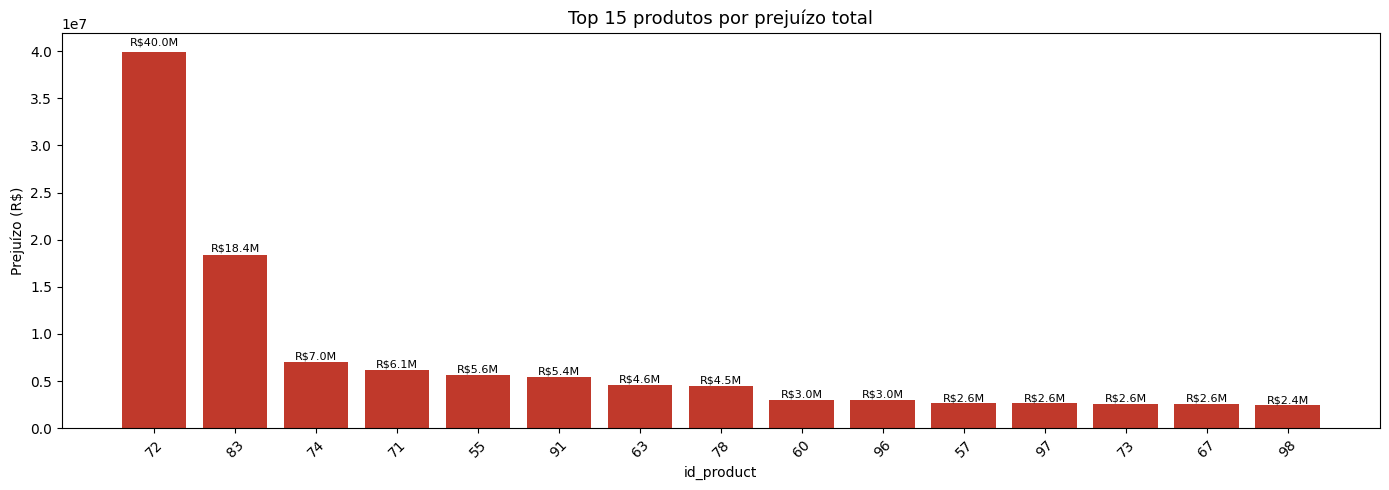

In [22]:
import matplotlib.pyplot as plt

# Pega só os top 15 produtos por prejuízo para o gráfico ficar legível
df_plot = df_prejuizo.head(15)

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(df_plot['id_product'].astype(str), df_plot['prejuizo_total'], color='#c0392b')

# Rótulos no topo de cada barra
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"R${bar.get_height()/1e6:.1f}M", ha='center', va='bottom', fontsize=8)

ax.set_title('Top 15 produtos por prejuízo total', fontsize=13)
ax.set_xlabel('id_product')
ax.set_ylabel('Prejuízo (R$)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Parte 3 - Análise objetiva

In [23]:
maior_prejuizo_abs = df_prejuizo.iloc[0]
maior_pct_perda = df_prejuizo.sort_values('pct_perda', ascending=False).iloc[0]

print("Produto com MAIOR prejuízo absoluto:")
print(f"  id_product: {maior_prejuizo_abs['id_product']}  |  prejuízo: R$ {maior_prejuizo_abs['prejuizo_total']:,.2f}")

print("\nProduto com MAIOR % de perda:")
print(f"  id_product: {maior_pct_perda['id_product']}  |  % perda: {maior_pct_perda['pct_perda']}%")

print("\nSão o mesmo produto?", maior_prejuizo_abs['id_product'] == maior_pct_perda['id_product'])

Produto com MAIOR prejuízo absoluto:
  id_product: 72.0  |  prejuízo: R$ 39,959,694.85

Produto com MAIOR % de perda:
  id_product: 72.0  |  % perda: 63.37%

São o mesmo produto? True


### Q4.2 - Validação
Produto com maior percentual de perda financeira relativa: **id_produto 72 — 63,37% de perda**

### Q4.3 - Interpretação
**Qual data de câmbio foi utilizada?**  
A cotação de venda do dólar comercial do dia da venda, obtida via API do Banco Central (PTAX). Para fins de semana e feriados sem cotação, aplicou-se forward fill (ffill) — ou seja, propaga-se a última cotação disponível.

**Como o prejuízo foi definido?**  
Prejuízo ocorre quando o custo total em BRL da transação (`usd_price × taxa_cambio × qtd`) supera o valor de venda registrado em `total`. Apenas transações com `custo_brl > total` são contabilizadas como perda.

**Suposições relevantes**  
O custo em USD é unitário e o preço de custo vigente é o mais recente antes da data de venda (merge_asof). Impostos e frete foram ignorados conforme premissa do desafio.

### Parte 1 - Limpeza e cruzamento

Com a limpeza das categorias já feita na Q2, aqui cruza-se as vendas com o catálogo 
de produtos para trazer a categoria de cada transação e então calcular 
a diversidade por cliente.

In [24]:
# Junta vendas com produtos limpos para ter a categoria por transação
df_q5 = df_vendas.merge(
    df_produtos[['code', 'category']],
    left_on='id_product',
    right_on='code',
    how='left'
)

print("Nulos em category:", df_q5['category'].isna().sum())
print(df_q5[['id_client', 'id_product', 'total', 'category']].head())

Nulos em category: 0
   id_client  id_product     total     category
0         42         105    3405.0    ancoragem
1          3         136   16873.9    ancoragem
2         25         139    9475.3    ancoragem
3         20          23   55893.0  eletrônicos
4          8          57  451403.9    propulsão


### Parte 2 - Cálculo de métricas e filtro de elite

Cliente fiel aqui, não é quem compra mais vezes, é quem tem gasto médio alto 
e navega por categorias diferentes. O filtro de 3+ categorias garante isso.

In [25]:
# Calcula faturamento, frequência, ticket médio e diversidade de categorias
df_clientes = df_q5.groupby('id_client').agg(
    faturamento_total=('total', 'sum'),
    frequencia=('id', 'count'),
    diversidade=('category', 'nunique')
).reset_index()

df_clientes['ticket_medio'] = df_clientes['faturamento_total'] / df_clientes['frequencia']

# Filtra só clientes com 3+ categorias distintas
df_elite = df_clientes[df_clientes['diversidade'] >= 3]

# Top 10 por ticket médio, desempate por id_client crescente
df_top10 = df_elite.sort_values(['ticket_medio', 'id_client'], ascending=[False, True]).head(10)

print(df_top10[['id_client', 'ticket_medio', 'diversidade', 'frequencia']].to_string(index=False))

 id_client  ticket_medio  diversidade  frequencia
        47 334991.747772            3         202
        42 319059.596336            3         232
        46 311805.458867            3         203
         9 310672.413889            3         234
        36 301521.448696            3         230
         2 300964.690000            3         225
        22 298318.472000            3         200
        28 298268.631136            3         220
        26 297558.483036            3         224
         5 290815.536667            3         210


### Parte 3 - Categoria mais comprada pelos Top 10

In [26]:
# Filtra vendas só dos top 10 clientes
top10_ids = df_top10['id_client'].tolist()
df_top10_vendas = df_q5[df_q5['id_client'].isin(top10_ids)]
# Categoria com maior soma de qtd
categoria_top = df_top10_vendas.groupby('category')['qtd'].sum().sort_values(ascending=False)
print(categoria_top)

category
propulsão      6429
ancoragem      6003
eletrônicos    5376
Name: qtd, dtype: int64


### Q5.1 - SQL com DuckDB

In [27]:
resultado_q5_sql = conn.execute("""
WITH metricas AS (
    SELECT
        v.id_client,
        SUM(v.total)               AS faturamento_total,
        COUNT(v.id)                AS frequencia,
        COUNT(DISTINCT p.category) AS diversidade,
        SUM(v.total) / COUNT(v.id) AS ticket_medio
    FROM df_vendas v
    LEFT JOIN df_produtos p ON v.id_product = p.code
    GROUP BY v.id_client
),
top10 AS (
    SELECT * FROM metricas
    WHERE diversidade >= 3
    ORDER BY ticket_medio DESC, id_client ASC
    LIMIT 10
)
SELECT p.category, SUM(v.qtd) AS total_itens
FROM df_vendas v
JOIN df_produtos p ON v.id_product = p.code
WHERE v.id_client IN (SELECT id_client FROM top10)
GROUP BY p.category
ORDER BY total_itens DESC
""").df()

print(resultado_q5_sql)

      category  total_itens
0    propulsão       6429.0
1    ancoragem       6003.0
2  eletrônicos       5376.0


### Q5.2 - Validação
Categoria mais comprada pelos Top 10 clientes: **propulsão** com 6.429 itens vendidos

### Q5.3 - Explicação
As categorias no dataset original estavam com variações de escrita, letras embaralhadas, espaços no meio. <br>
Tudo foi normalizado na Q2 usando uma função que remove acentos, espaços internos e padroniza para minúsculo. <br>
Mapeando por substring para as 3 categorias válidas. Para o filtro de diversidade usou-se __COUNT(DISTINCT category) >= 3__ no agrupamento por cliente.<br>
 A contagem de itens dos Top 10 foi feita filtrando as vendas pelo __id_client__ dos clientes selecionados antes de agregar por categoria.

## __Q6 - Dimensão de Calendário__

### Cenário
O Sr. Almir quer saber qual dia da semana tem a pior média de vendas para decidir se vale fechar a loja nesses dias. <br>

### Q6.1 - SQL com DuckDB

Um GROUP BY direto na tabela de vendas ignora os dias sem registro, dias que a loja abriu mas não vendeu nada, o que infla a média. <br>
A solução é gerar um calendário completo do período fazendo um LEFT JOIN com as vendas, tratando os dias sem registro como zero.

In [ ]:
# Dimensão de datas com DuckDB
resultado_q6 = conn.execute("""
WITH calendario AS (
    -- Gera todas as datas do período
    SELECT UNNEST(generate_series(
        MIN(sale_date)::DATE,
        MAX(sale_date)::DATE,
        INTERVAL '1 day'
    )) AS data
    FROM df_vendas
),
vendas_dia AS (
    SELECT sale_date::DATE AS data, SUM(total) AS valor_venda
    FROM df_vendas
    GROUP BY sale_date::DATE
),
calendario_vendas AS (
    SELECT
        c.data,
        COALESCE(v.valor_venda, 0) AS valor_venda,
        CASE DAYOFWEEK(c.data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario c
    LEFT JOIN vendas_dia v ON c.data = v.data
)
SELECT
    dia_semana,
    ROUND(AVG(valor_venda), 2) AS media_vendas
FROM calendario_vendas
GROUP BY dia_semana
ORDER BY media_vendas ASC
""").df()

print(resultado_q6)

      dia_semana  media_vendas
0        Domingo    3229614.16
1  Segunda-feira    3484500.47
2    Terça-feira    3488871.99
3   Quarta-feira    3534007.21
4   Quinta-feira    3713299.94
5         Sábado    3774290.79
6    Sexta-feira    3776151.25


### Q6.2 — Validação
Dia com menor média de vendas: **Domingo** com R$ 3.229.614,16

### Q6.3 — Explicação
Sem uma tabela de datas, dias sem venda simplesmente não existem no dataset. O GROUP BY os ignora e a média fica maior do que deveria. Com o calendário, garantimos que todos os dias do período entram no cálculo, com zero onde não houve venda. Se um dia da semana tiver muitos dias sem venda, sua média cai proporcionalmente, exatamente o que o estagiário do enunciado acabou não considerando.

## __Q7 - Previsão de Demanda__

### Cenário
O Sr. Almir quer um modelo que preveja quantas unidades do **Motor de Popa Yamaha Evo Dash 155HP** serão vendidas em Janeiro de 2024, para ajustar o estoque com antecedência.

### Premissas
- Treino: dados até **31/12/2023**
- Teste: **Janeiro de 2024** (base diária)
- Modelo: **média móvel dos últimos 7 dias**
- Dias sem venda recebem **qtd = 0**
- Sem data leakage: cada previsão usa apenas dados **anteriores** à data prevista

### Parte 1 - Preparação dos dados

Filtra as vendas do produto alvo, agrupa por dia e cria um calendário completo
para que dias sem venda entrem com `qtd = 0`.

In [29]:
# Filtra o produto alvo
produto_alvo = "Motor de Popa Yamaha Evo Dash 155HP"

# Busca o id do produto
id_alvo = df_produtos[df_produtos['name'] == produto_alvo]['code'].values[0]
print("ID do produto:", id_alvo)

# Agrupa vendas diárias do produto
df_motor = df_q5[df_q5['id_product'] == id_alvo][['sale_date', 'qtd']].copy()
df_motor['sale_date'] = pd.to_datetime(df_motor['sale_date'])
df_motor = df_motor.groupby('sale_date')['qtd'].sum().reset_index()

print(f"Registros de venda: {len(df_motor)}")
print(df_motor.head())

ID do produto: 54
Registros de venda: 58
   sale_date  qtd
0 2023-01-10    3
1 2023-02-06   13
2 2023-02-27   15
3 2023-03-04   14
4 2023-03-15    4


### Parte 2 - Modelo baseline e avaliação

A cada dia de Janeiro/2024, a previsão é a média das últimas 7 vendas diárias conhecidas.
Após prever, o valor real daquele dia é adicionado ao histórico, simulando como o modelo
funcionaria em produção, sem acesso a dados futuros.

In [30]:
# Cria calendário completo e preenche dias sem venda com 0
datas = pd.date_range('2023-01-01', '2024-12-31')
df_motor_full = pd.DataFrame({'sale_date': datas})
df_motor_full = df_motor_full.merge(df_motor, on='sale_date', how='left')
df_motor_full['qtd'] = df_motor_full['qtd'].fillna(0)

# Separa treino e teste
treino = df_motor_full[df_motor_full['sale_date'] <= '2023-12-31'].copy()
teste  = df_motor_full[(df_motor_full['sale_date'] >= '2024-01-01') &
                       (df_motor_full['sale_date'] <= '2024-01-31')].copy()

# Média móvel 7 dias — só dados anteriores à data prevista (sem data leakage)
historico = treino['qtd'].tolist()
previsoes = []

for i in range(len(teste)):
    janela = historico[-7:]
    previsoes.append(round(sum(janela) / len(janela), 4))
    historico.append(teste['qtd'].iloc[i])  # adiciona real ao histórico após prever

teste['previsao'] = previsoes

# MAE
mae = (teste['qtd'] - teste['previsao']).abs().mean()
print(f"MAE: {mae:.4f}")
print(f"\nSoma previsão 01/01 a 07/01: {round(teste[teste['sale_date'] <= '2024-01-07']['previsao'].sum())}")
print(teste[['sale_date', 'qtd', 'previsao']].head(10))

MAE: 1.6406

Soma previsão 01/01 a 07/01: 3
     sale_date   qtd  previsao
365 2024-01-01   0.0    0.0000
366 2024-01-02   0.0    0.0000
367 2024-01-03   0.0    0.0000
368 2024-01-04   0.0    0.0000
369 2024-01-05  10.0    0.0000
370 2024-01-06   0.0    1.4286
371 2024-01-07   0.0    1.4286
372 2024-01-08   0.0    1.4286
373 2024-01-09   0.0    1.4286
374 2024-01-10   0.0    1.4286


### Q7.2 — Validação
Soma da previsão de 01/01 a 07/01/2024: **3 unidades**

### Q7.3 — Explicação
**1. Como o baseline foi construído?**  
Para cada dia de Janeiro/2024, calculou-se a média das últimas 7 vendas diárias anteriores à data prevista. Os dias sem venda foram incluídos como zero, garantindo que períodos de baixa demanda sejam representados corretamente.

**2. Como evitou data leakage?**  
O histórico de treino inclui apenas dados até 31/12/2023. A cada iteração, o valor real do dia é adicionado ao histórico somente **após** a previsão ser gerada, nunca antes.

**3. Uma limitação do modelo proposto**  
A média móvel simples não captura sazonalidade nem tendência. Para um produto de venda esporádica como este, 58 dias com venda em 2 anos, o modelo tende a prever valores próximos de zero na maior parte do tempo, perdendo picos de demanda.

## __Q8 - Sistema de Recomendação__

### Cenário
A Marina quer implementar uma vitrine de recomendação no site: clientes que compram um produto recebem sugestões do que outros clientes levaram junto.
O produto de referência é o **GPS Garmin Vortex Maré Drift**.

### Abordagem
1. Construção de uma **matriz usuário x produto** (1 se comprou, 0 se não)
2. Cálculo da **Similaridade de Cosseno** entre vetores de produtos
3. Ranking dos **5 produtos mais similares** ao GPS de referência

In [31]:
import numpy as np

# Matriz usuário-produto (1 se comprou, 0 se não)
df_matrix = df_vendas.groupby(['id_client', 'id_product'])['qtd'].sum().reset_index()
df_matrix['comprou'] = 1
matriz = df_matrix.pivot_table(index='id_client', columns='id_product', values='comprou', fill_value=0)

# ID do GPS Garmin Vortex Maré Drift
id_gps = df_produtos[df_produtos['name'] == 'GPS Garmin Vortex Maré Drift']['code'].values[0]
print("ID do GPS:", id_gps)

# Similaridade de cosseno entre produtos
M = matriz.values.T  # produtos nas linhas
normas = np.linalg.norm(M, axis=1, keepdims=True)
normas[normas == 0] = 1  # evita divisão por zero
M_norm = M / normas
sim_matrix = M_norm @ M_norm.T

# Ranking dos 5 mais similares ao GPS
produtos_ids = matriz.columns.tolist()
idx_gps = produtos_ids.index(id_gps)
similares = sim_matrix[idx_gps]

ranking = sorted(enumerate(similares), key=lambda x: x[1], reverse=True)
ranking = [(produtos_ids[i], s) for i, s in ranking if produtos_ids[i] != id_gps][:5]

print("\nTop 5 produtos similares ao GPS:")
for pid, sim in ranking:
    nome = df_produtos[df_produtos['code'] == pid]['name'].values
    print(f"  id: {pid}  |  sim: {sim:.4f}  |  {nome[0] if len(nome) else 'N/A'}")

ID do GPS: 27

Top 5 produtos similares ao GPS:
  id: 94  |  sim: 0.8696  |  Motor de Popa Volvo Magnum 276HP
  id: 11  |  sim: 0.8680  |  GPS Furuno Swift Leviathan Poseidon
  id: 35  |  sim: 0.8539  |  Radar Furuno Swift
  id: 1  |  sim: 0.8500  |  Transponder AIS Maré Magnum
  id: 115  |  sim: 0.8500  |  Cabo de Nylon Delta Force Magnum Leviathan


### Q8.2 Validação
Produto com maior similaridade ao GPS Garmin Vortex Maré Drift: <br>
&nbsp;&nbsp;&nbsp;**R: id 94, Motor de Popa Volvo Magnum 276HP** (similaridade: 0.8696)

### Q8.3 Explicação
**1. Como a matriz foi construída?**  
Cada linha representa um **id_client**, cada coluna um **id_product**. O valor da célula é 1 se o cliente comprou ao menos uma vez aquele produto, e 0 caso contrário. A quantidade comprada é ignorada, apenas presença ou ausência importa.

**2. O que significa a similaridade de cosseno nesse contexto?**  
Mede a similaridade (o ângulo entre os vetores) de dois produtos no espaço de clientes. <br>
O valor varia de 0 a 1. Sendo 0 = nenhum cliente em comum, e 1 = exatamente os mesmos clientes. <br>

**3. Uma limitação desse método de recomendação**  
Produtos novos, com poucos compradores, terão vetores próximos de zero e não serão bem recomendados. <br>
Além disso, produtos muito populares podem aparecer no ranking apenas por terem muitos compradores, e não por afinidade real com o produto de referência.